# 1

### (a) Centered Data

$\bar x = 1.81$

$\bar y = 1.9099999999999997$

centered_x,centered_y
0.6900,0.4900
-1.3100,-1.2100
0.3900,0.9900
0.0900,0.2900
1.2900,1.0900
0.4900,0.7900
0.1900,-0.3100
-0.8100,-0.8100
-0.3100,-0.3100
-0.7100,-1.0100


### (b) Covariance Matrix

...

### (c) Eigenvalues and Eigenvectors

Principal Component,Eigenvalue,Eigenvector x-component,Eigenvector y-component
PC1,1.284028,-0.677873,-0.735179
PC2,0.049083,-0.735179,0.677873


#### Eigenvectors Scaled by $\sqrt{\lambda}$

Principal Component,sqrt(Eigenvalue),Scaled vector x-component,Scaled vector y-component
PC1,1.133149,-0.768132,-0.833067
PC2,0.221548,-0.162877,0.150181


### (d) Visualize Geometry

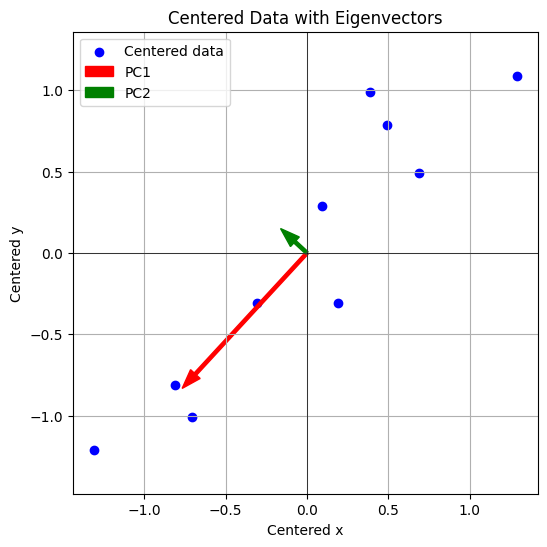

In [4]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, HTML
import matplotlib.pyplot as plt

# -----------------------------
# Data
# -----------------------------
X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
])

# -----------------------------
# Calculations
# -----------------------------
mean = np.mean(X, axis=0)
X_centered = X - mean

cov_matrix = np.cov(X_centered.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort largest eigenvalue first
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

scaled_vectors = eigenvectors * np.sqrt(eigenvalues)

# -----------------------------
# Markdown / HTML Output
# -----------------------------

display(Markdown("### (a) Centered Data"))

mean_df = pd.DataFrame({
    "mean_x": [mean[0]],
    "mean_y": [mean[1]]
})

display(Markdown(f'$\\bar x = {mean[0]}$'))
display(Markdown(f'$\\bar y = {mean[1]}$'))

centered_df = pd.DataFrame(
    X_centered,
    columns=["centered_x", "centered_y"]
)

display(HTML(centered_df.to_html(index=False, float_format="%.4f")))

display(Markdown("### (b) Covariance Matrix"))

cov_df = pd.DataFrame(
    cov_matrix,
    columns=["x", "y"],
    index=["x", "y"]
)

display(HTML(cov_df.to_html(float_format="%.6f")))

display(Markdown("### (c) Eigenvalues and Eigenvectors"))

eig_df = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Eigenvalue": eigenvalues,
    "Eigenvector x-component": eigenvectors[0, :],
    "Eigenvector y-component": eigenvectors[1, :]
})

display(HTML(eig_df.to_html(index=False, float_format="%.6f")))

display(Markdown("#### Eigenvectors Scaled by $\\sqrt{\\lambda}$"))

scaled_df = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "sqrt(Eigenvalue)": np.sqrt(eigenvalues),
    "Scaled vector x-component": scaled_vectors[0, :],
    "Scaled vector y-component": scaled_vectors[1, :]
})

display(HTML(scaled_df.to_html(index=False, float_format="%.6f")))

# -----------------------------
# Plot
# -----------------------------
display(Markdown("### (d) Visualize Geometry"))
plt.figure(figsize=(6, 6))

plt.scatter(
    X_centered[:, 0],
    X_centered[:, 1],
    color="blue",
    label="Centered data"
)

colors = ["red", "green"]

for i in range(2):
    plt.arrow(
        0, 0,
        scaled_vectors[0, i],
        scaled_vectors[1, i],
        color=colors[i],
        width=0.02,
        head_width=0.08,
        length_includes_head=True,
        label=f"PC{i+1}"
    )

plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.grid(True)
plt.axis("equal")
plt.xlabel("Centered x")
plt.ylabel("Centered y")
plt.title("Centered Data with Eigenvectors")
plt.legend()
plt.show()

### (e) What does each eigenvector represent geometrically?
Each eigenvector gives a principal direction of the data. The first eigenvector, for PC1 (principal component 1), points in the direction where the data varies the most. The second eigenvector, for PC2 (principal component 2), is perpendicular to the first and points in the direction where the data varies the least. Geometrically, they describe the main axes of the elliptical shape formed by the data cloud.

### (f) How do the eigenvalues relate to spread?
The eigenvalues measure the variance of the data along their corresponding eigenvectors. The first eigenvalue, for PC1, is much larger than the second eigenvalue, for PC2. This means that there is very large spread for the first eigenvector and very little spread for the second eigenvector. The data is stretched mostly along the first eigenvector.

### (g) If compressing to 1D, which eigenvector should we project onto?
We should project onto the eigenvector with the largest eigenvalue because it preserves the most variance in the dataset. So, we should project onto the eigenvector of PC1.

# 2
### (a) Compute the SVD
#### Step 1 - Enter the original data

In [6]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, HTML

X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
])

data_df = pd.DataFrame(X, columns=["x", "y"])
display(HTML(data_df.to_html(index=False, float_format="%.4f")))

x,y
2.5000,2.4000
0.5000,0.7000
2.2000,2.9000
1.9000,2.2000
3.1000,3.0000
2.3000,2.7000
2.0000,1.6000
1.0000,1.1000
1.5000,1.6000
1.1000,0.9000


#### Step 2 - Center the data

We subtract the mean of each column from every row. Let $X_c$ be the centered data matrix where:

$$
X_c = X - \bar{X}
$$

In [8]:
mean = np.mean(X, axis=0)
X_centered = X - mean

mean_df = pd.DataFrame({
    "mean_x": [mean[0]],
    "mean_y": [mean[1]]
})

display(Markdown("###### Column Means"))
display(HTML(mean_df.to_html(index=False, float_format="%.4f")))

centered_df = pd.DataFrame(X_centered, columns=["centered_x", "centered_y"])

display(Markdown("###### Centered Data Matrix"))
display(HTML(centered_df.to_html(index=False, float_format="%.4f")))

###### Column Means

mean_x,mean_y
1.8100,1.9100


###### Centered Data Matrix

centered_x,centered_y
0.6900,0.4900
-1.3100,-1.2100
0.3900,0.9900
0.0900,0.2900
1.2900,1.0900
0.4900,0.7900
0.1900,-0.3100
-0.8100,-0.8100
-0.3100,-0.3100
-0.7100,-1.0100


#### Step 3 - Compute the SVD

In [9]:
U, singular_values, Vt = np.linalg.svd(X_centered, full_matrices=False)
V = Vt.T

#### Step 4 - Display the singular values

In [10]:
singular_df = pd.DataFrame({
    "Singular Value": ["sigma_1", "sigma_2"],
    "Value": singular_values
})

display(HTML(singular_df.to_html(index=False, float_format="%.6f")))

Singular Value,Value
sigma_1,3.399448
sigma_2,0.664643


#### Step 5 - Display the right singular vectors

The right singular vectors are the columns of $V$.

In [12]:
V_df = pd.DataFrame(
    V,
    columns=["v1", "v2"],
    index=["x-component", "y-component"]
)

display(HTML(V_df.to_html(float_format="%.6f")))

,v1,v2
x-component,-0.677873,0.735179
y-component,-0.735179,-0.677873


[[-0.6778734   0.73517866]
 [-0.73517866 -0.6778734 ]]


#### Step 6 - Compare with covariance eigenvectors

From PCA, the eigenvectors of the covariance matrix should match the right singular vectors of the centered data matrix. This is because:

$$
X_c^TX_c = V \Sigma^2 V^T
$$

And, the sample covariance matrix $C$ is:

$$
C = \frac{1}{n-1}X_c^T X_c
$$

So the covariance matrix has the same eigenvectors as $X_c^T X_c$, which are the columns of $V$. Note that "matching eigenvectors" means these vectors point in the same directions. They may differ by a sign, since both $v$ and $-v$ describe the same axis. The associated singular values and covariance eigenvalues are not the same, because the covariance matrix includes the scaling factor $\frac{1}{n-1}$.

### (b) Construct Rank-1 Approximation
This keeps only the largest singular value, $\sigma_1$, and its corresponding singular vectors. Geometrically, this means we are projecting the centered data onto the one-dimensional subspace spanned by the first right singular vector $v_1$.

#### Step 1 - Construct the rank-1 approximation $X_1$

We use only the largest singular value $\sigma_1$, the first left singular vector $u_1$, and the first right singular vector $v_1$.

$$
X_1 = \sigma_1 u_1 v_1^T
$$

In [13]:
# Get the largest singular value and corresponding singular vectors
sigma_1 = singular_values[0]
u_1 = U[:, 0].reshape(-1, 1)
v_1 = V[:, 0].reshape(-1, 1)

# Construct the rank-1 approximation
X_1 = sigma_1 * u_1 @ v_1.T

# Display the reconstructed rank-1 points
rank1_df = pd.DataFrame(
    X_1,
    columns=["rank1_x", "rank1_y"]
)

display(HTML(rank1_df.to_html(index=False, float_format="%.6f")))

rank1_x,rank1_y
0.561259,0.608706
-1.204974,-1.306839
0.672584,0.729442
0.185880,0.201594
1.135981,1.232013
0.618864,0.671181
-0.067184,-0.072863
-0.775875,-0.841465
-0.296940,-0.322042
-0.829595,-0.899727


#### Step 2 - Plot the original centered data

The original centered data points are the rows of $X_c$.

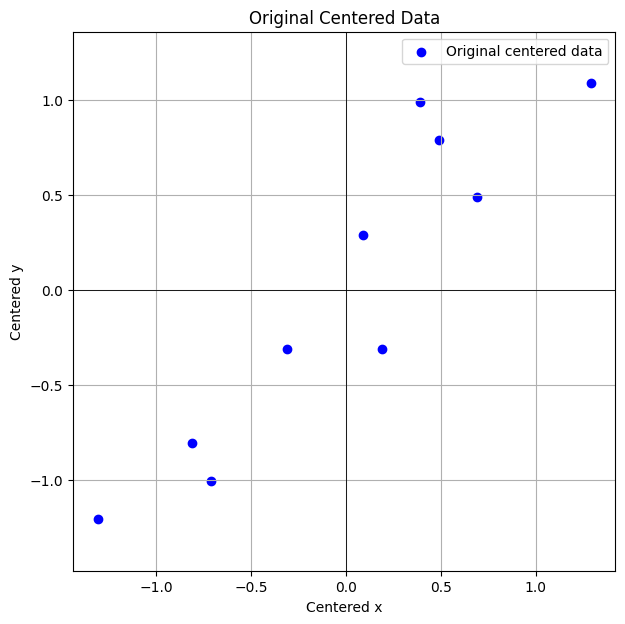

In [14]:
plt.figure(figsize=(7, 7))

plt.scatter(
    X_centered[:, 0],
    X_centered[:, 1],
    color="blue",
    label="Original centered data"
)

plt.axhline(0, color="black", linewidth=0.6)
plt.axvline(0, color="black", linewidth=0.6)
plt.xlabel("Centered x")
plt.ylabel("Centered y")
plt.title("Original Centered Data")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

#### Step 3 - Plot the reconstructed rank-1 points

The reconstructed rank-1 points are the rows of $X_1$.

Since $X_1$ is rank-1, all reconstructed points lie on the one-dimensional line spanned by $v_1$.

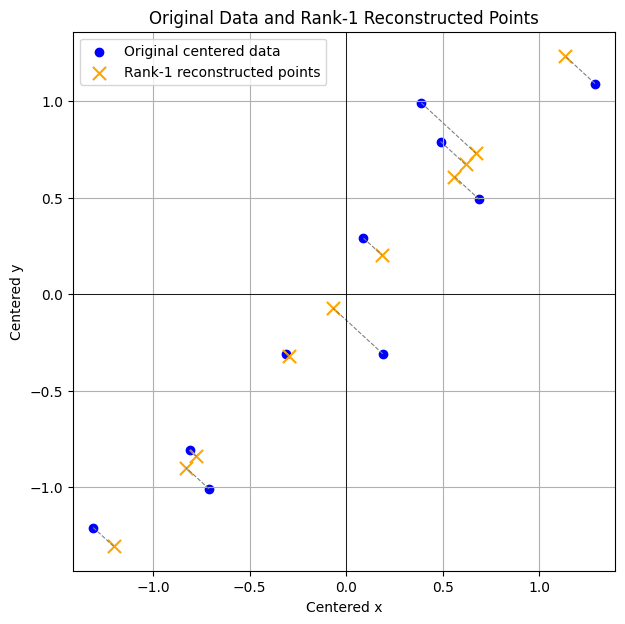

In [15]:
plt.figure(figsize=(7, 7))

# Original centered data
plt.scatter(
    X_centered[:, 0],
    X_centered[:, 1],
    color="blue",
    label="Original centered data"
)

# Rank-1 reconstructed points
plt.scatter(
    X_1[:, 0],
    X_1[:, 1],
    color="orange",
    marker="x",
    s=90,
    label="Rank-1 reconstructed points"
)

# Draw dashed lines from original points to reconstructed points
for i in range(X_centered.shape[0]):
    plt.plot(
        [X_centered[i, 0], X_1[i, 0]],
        [X_centered[i, 1], X_1[i, 1]],
        color="gray",
        linestyle="--",
        linewidth=0.8
    )

plt.axhline(0, color="black", linewidth=0.6)
plt.axvline(0, color="black", linewidth=0.6)
plt.xlabel("Centered x")
plt.ylabel("Centered y")
plt.title("Original Data and Rank-1 Reconstructed Points")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

#### Step 4 - Draw the dominant direction $v_1$

The vector $v_1$ is the first right singular vector. It gives the dominant direction of variation in the centered dataset.

We draw $v_1$ as an arrow from the origin. For visibility, we scale the arrow.

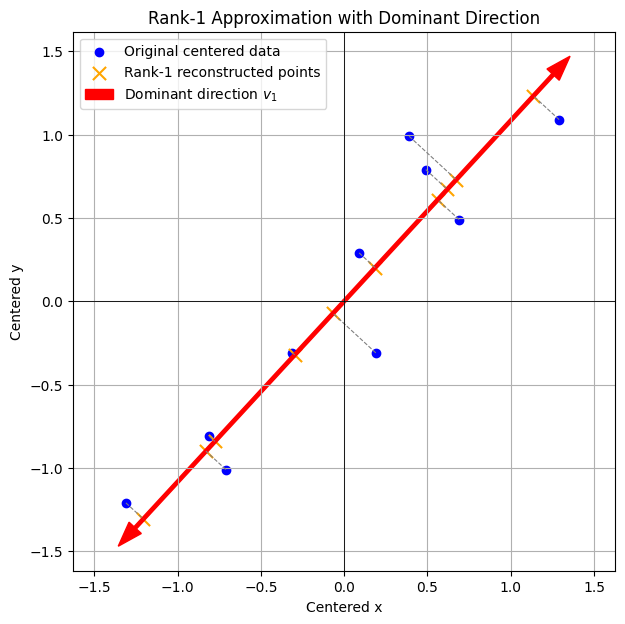

In [16]:
plt.figure(figsize=(7, 7))

# Original centered data
plt.scatter(
    X_centered[:, 0],
    X_centered[:, 1],
    color="blue",
    label="Original centered data"
)

# Rank-1 reconstructed points
plt.scatter(
    X_1[:, 0],
    X_1[:, 1],
    color="orange",
    marker="x",
    s=90,
    label="Rank-1 reconstructed points"
)

# Draw dashed lines from original points to reconstructed points
for i in range(X_centered.shape[0]):
    plt.plot(
        [X_centered[i, 0], X_1[i, 0]],
        [X_centered[i, 1], X_1[i, 1]],
        color="gray",
        linestyle="--",
        linewidth=0.8
    )

# Draw dominant direction v_1
scale = 2.0
v1_arrow = scale * V[:, 0]

plt.arrow(
    0, 0,
    v1_arrow[0],
    v1_arrow[1],
    color="red",
    width=0.02,
    head_width=0.10,
    length_includes_head=True,
    label="Dominant direction $v_1$"
)

# Draw the opposite direction too, to show the full line/axis
plt.arrow(
    0, 0,
    -v1_arrow[0],
    -v1_arrow[1],
    color="red",
    width=0.02,
    head_width=0.10,
    length_includes_head=True
)

plt.axhline(0, color="black", linewidth=0.6)
plt.axvline(0, color="black", linewidth=0.6)
plt.xlabel("Centered x")
plt.ylabel("Centered y")
plt.title("Rank-1 Approximation with Dominant Direction")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

### (C)
#### Step 1 - Compute $\sigma_1^2$ and $\sigma_2^2$

In [17]:
sigma_1_squared = singular_values[0] ** 2
sigma_2_squared = singular_values[1] ** 2

sigma_squared_df = pd.DataFrame({
    "Quantity": ["sigma_1^2", "sigma_2^2"],
    "Value": [sigma_1_squared, sigma_2_squared]
})

display(HTML(sigma_squared_df.to_html(index=False, float_format="%.6f")))

Quantity,Value
sigma_1^2,11.556249
sigma_2^2,0.441751


#### Step 2 - Compute the total variation

In [18]:
total_variation = sigma_1_squared + sigma_2_squared

total_df = pd.DataFrame({
    "Quantity": ["Total variation"],
    "Value": [total_variation]
})

display(HTML(total_df.to_html(index=False, float_format="%.6f")))

Quantity,Value
Total variation,11.998000


#### Step 3 - Compute the fraction captured by keeping only $\sigma_1$

In [19]:
fraction_captured = sigma_1_squared / total_variation
percent_captured = 100 * fraction_captured

fraction_df = pd.DataFrame({
    "Quantity": [
        "Fraction captured by sigma_1",
        "Percent captured by sigma_1"
    ],
    "Value": [
        fraction_captured,
        percent_captured
    ]
})

display(HTML(fraction_df.to_html(index=False, float_format="%.6f")))

Quantity,Value
Fraction captured by sigma_1,0.963181
Percent captured by sigma_1,96.318131


#### Step 4 - What the Small Singular Value Represents

The smaller singular value $\sigma_2$ represents the amount of variation in the direction perpendicular to the dominant direction $v_1$.

Since $\sigma_2$ is much smaller than $\sigma_1$, the data has much less spread in the second direction. Geometrically, this means the data cloud is long and narrow: most of its variation lies along $v_1$, while only a small amount lies along the second direction $v_2$.

### (d) Why does keeping only the largest singular value "compress" the dataset?

Keeping only the largest singular value compresses the dataset because it reduces the data from two dimensions to one dominant direction. Instead of representing each point using both original coordinates, the rank-1 approximation represents each point mainly by how far it lies along the dominant direction $v_1$. So we keep the most important pattern in the data while discarding the weaker direction.

### (e) What kind of structure is preserved in a rank-1 approximation?

A rank-1 approximation preserves the strongest linear structure in the dataset. In this case, it preserves the main diagonal trend of the data cloud, which is the direction where the data has the most variation. The reconstructed points lie along one line, the line spanned by $v_1$.

### (f) If this dataset contained noise, how might low-rank approximation help?

If the dataset contained noise, low-rank approximation could help by removing small variations in weaker directions. Noise often appears as small, scattered deviations away from the main trend. By keeping only the largest singular value, we preserve the main signal and discard smaller components that may be noise. So low-rank approximation can act like a denoising method.


# 3 Preparing to Apply PCA to MNIST

### (a)

If we select 2,000 MNIST images, and each image is flattened into a vector of length 784, then the data matrix has shape:

$X \in \mathbb{R}^{2000 \times 784}$

So the shape of $X$ is:

$\boxed{2000 \times 784}$

Each row represents one image, and each column represents one pixel location.

### (b)

MNIST is considered high-dimensional data because each image has 784 features.

Each image is originally a $28 \times 28$ grayscale image. Since:

$28 \times 28 = 784$

each image becomes a point in a 784-dimensional space after being flattened. Each pixel location is treated as a separate feature.

### (c)

Centering means subtracting the mean value of each pixel column from every image.

In other words, for each pixel location, we compute the average pixel intensity across all selected images. Then we subtract that average from every image at that pixel location.

Centering is needed before computing the covariance matrix because PCA studies how the data varies around the mean. If the data is not centered, the covariance matrix may be affected by the average brightness or average digit shape instead of the true variation among the images.

### (d)

Some visual differences that could create large variation across MNIST digit images include:

- Stroke thickness
- Slant, such as leaning left or right
- Digit size
- Position of the digit in the image, such as shifted up, down, left, or right
- Different handwriting styles
- Shape differences, such as different ways of writing a 2 or 7
- Loops and curves, such as in 0, 6, 8, and 9
- Straight versus curved strokes
- Overall brightness or darkness

PCA finds directions that capture these major patterns of variation across the images.

### (e)

In the MNIST setting, $V_k$ and $Y = X_\mu V_k$ have different meanings. $V_k$ contains the top $k$ principal directions. Each principal direction is a vector in the original 784-dimensional pixel space. These directions describe important patterns of variation in the images. For MNIST, a principal direction can be thought of as an image-like pattern showing where pixels tend to vary together. $Y = X_\mu V_k$ is the lower-dimensional representation of the images. Instead of representing each image with 784 pixel values, each image is represented by $k$ PCA scores.

If:

$$X_\mu \in \mathbb{R}^{n \times 784}$$

And:

$$V_k \in \mathbb{R}^{784 \times k}$$

Then:

$$Y \in \mathbb{R}^{n \times k}$$

So:

- $V_k$ contains the principal directions.
- $Y$ contains the coordinates, or PCA scores, of each image after projection onto those directions.

### (f)

The cumulative explained variance table is:

| Number of components | Cumulative explained variance |
|----------------------|-------------------------------|
| 10                   | 45%                           |
| 25                   | 65%                           |
| 50                   | 80%                           |
| 100                  | 91%                           |
| 150                  | 95%                           |
| 300                  | 99%                           |

If the goal is to preserve at least 95% of the variance, the smallest listed value of $k$ is:

$\boxed{150}$

### (g)

Choosing $k$ is a tradeoff between keeping information and reducing dimensionality.

A larger value of $k$ keeps more of the original variation in the data, but it also means the data is not reduced as much. A smaller value of $k$ gives stronger dimensionality reduction, but it may lose more information.

For example:

- Larger $k$: more information kept, less compression
- Smaller $k$: more compression, more information lost

The goal is to choose a value of $k$ that keeps enough important information while still making the data simpler to work with.

### (h)

If we project MNIST images onto the first two principal components and color the points by digit labels, some digits may form visible clusters because their shapes are very different from other digits.

For example, the digit 0 may form a cluster because it often has a round loop shape. The digit 1 may also separate because it is usually narrow and mostly vertical.

Other digits may overlap because they have similar shapes or handwriting styles. For example:

- 3 and 8 can both have curved shapes.
- 4 and 9 can sometimes look similar.
- 5 and 6 may overlap if they are written with similar curves.
- 1 and 7 may overlap depending on slant and handwriting style.

Also, the first two principal components only capture part of the total variation, so they may not be enough to perfectly separate all digit classes.

### (i)

PCA uses only the data matrix $X$, which contains the pixel values of the images. It does not use the digit labels when computing the principal components.

However, the labels can still help us interpret a PCA plot. After PCA is computed, we can color the projected points by their digit labels. This helps us see whether images of the same digit tend to appear near each other.

The labels help us answer questions such as:

- Do images of the same digit form clusters?
- Which digits overlap with each other?
- Are some digits more visually distinct than others?
- Do the principal components capture variation related to digit identity?

So the labels are not used to compute PCA, but they are useful for understanding and interpreting the PCA visualization.